# 🦴 RSNA Bone Age 전처리 파이프라인

소아 왼손 X-ray를 **손 영역만 정사각 크롭 + 배경 제거 + 마커 소거**하여 학습용으로 정규화합니다.

**핵심 설계**
- **마커를 크롭 *전에* 지움** — 손 바깥의 밝은 소형 blob(번인 텍스트: `L JCO`, `L CLT` 등)을 배경값으로 인페인팅
- **판(plate) 배제** — 연결요소의 `extent`(면적/bbox면적)로 사각 판(≈0.9~1.0)과 손 형태(≈0.4~0.6)를 구분
- **디스크 캐시** — 이미 처리된 파일은 스킵(중단 후 재개 가능)
- **QC 로그 + 2-pass 보정** — 실패(rescue) 이미지를 `suspects.csv`로 뽑고, `manual_bbox.csv`로 수동 재크롭

> 세그멘테이션(U-Net/SAM) 백엔드는 `SEG_BACKEND` 토글로 나중에 교체 가능. 현재 기본값은 다운로드 불필요한 `classical`.

**필요 패키지:** `pip install opencv-python numpy matplotlib pandas tqdm`


In [1]:
# ===== 임포트 & 한글 폰트 설정 =====
import cv2, time, csv
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

# Windows 한글 깨짐 방지 (Malgun Gothic = 윈도우 기본 한글 폰트)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print("OpenCV:", cv2.__version__)

OpenCV: 4.10.0


## 1. 설정 (경로 · 옵션 · 임계값)

In [2]:
# ===== 경로 (원본과 출력을 반드시 분리) =====
SRC_DIR = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터\Bone+Age+Training+Set\boneage-training-dataset")

BASE_OUT   = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터\전처리")  # 전처리 결과 저장 위치
OUTPUT_DIR = BASE_OUT / "images"                       # 전처리 이미지 저장
QC_DIR     = BASE_OUT / "qc"                           # QC 로그 / suspects
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QC_DIR.mkdir(parents=True, exist_ok=True)

# ===== 처리 옵션 =====
TARGET_SIZE   = 512          # 저장 해상도(정사각). 학습 입력(299)보다 크게 저장해 증강 여유 확보
SKIP_EXISTING = True         # 처리 완료 파일 스킵(디스크 캐시)
LIMIT         = None         # None = 전체 처리. 검증용으로 앞 N장만 볼 땐 정수로 변경
SEG_BACKEND   = "classical"  # "classical" | (향후) "unet" | "sam"

# ===== 크롭/검출 임계값 (필요 시 튜닝) =====
CLAHE_CLIP       = 2.0
CLAHE_TILE       = 8
PAD_FRAC         = 0.08      # bbox 여백 비율(손끝 잘림 방지 위해 상향)
MIN_AREA_FRAC    = 0.05      # 손으로 인정할 최소 면적 비율(이하 → rescue)
MAX_AREA_FRAC    = 0.95      # 이상이면 배경/판을 잡은 것 → rescue
HAND_EXTENT_LO   = 0.30      # 손 형태 extent 하한
HAND_EXTENT_HI   = 0.75      # 손 형태 extent 상한 (판 ≈0.9~1.0 은 여기서 걸러짐)
PLATE_EXTENT_TH  = 0.85      # 이 이상이면 사각 판으로 간주해 제외
MARKER_BRIGHT_TH = 200       # 마커로 볼 밝기 임계 (0~255)
MARKER_MAX_AREA  = 4000      # 마커로 볼 최대 blob 면적(px). 초과 시 마커 아님

# ===== 손 실루엣(피부/손끝 포함) 설정 =====
BG_MODE     = "keep"         # "keep"=배경 유지(가장 자연스러움) | "mask"=실루엣 밖만 0으로
SKIN_DELTA  = 12             # 배경 밝기 + 이 값 이상이면 손(피부 포함)으로 간주. 낮출수록 연한 피부/손끝까지 포함
SILH_DILATE = 7              # 실루엣 외곽/손끝 여유(px). 0이면 미적용

# ===== 밝기 정합 (최종모델 표8 3단계와 동일) =====
MATCH_BRIGHTNESS = True      # True면 '크기 통일(리사이즈) 전'에 히스토그램 평활화로 밝기/대비 분포를 정규화
                             # 최종모델(preprocess: crop->resize->equalizeHist)과 동일한 밝기 처리를 이 파이프라인에 부여

# ===== 모델 학습 전 제외할 이상 이미지 (파일명 stem) =====
EXCLUDE_IDS = {"1521","1607","1779","2256","2414","2823","3883","3885",
               "3899","3905","3931","3964","3999","4004","4230"}

print("원본:", SRC_DIR)
print("출력:", OUTPUT_DIR)
print("밝기 정합:", "ON (equalizeHist, 리사이즈 전)" if MATCH_BRIGHTNESS else "OFF")
print("제외 이미지:", len(EXCLUDE_IDS), "장")

원본: C:\Users\Win11Pro\Desktop\뼈데이터\Bone+Age+Training+Set\boneage-training-dataset
출력: C:\Users\Win11Pro\Desktop\뼈데이터\전처리\images
밝기 정합: ON (equalizeHist, 리사이즈 전)
제외 이미지: 15 장


## 2. 전처리 함수

In [3]:
_clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=(CLAHE_TILE, CLAHE_TILE))

def imread_u(path, flags=cv2.IMREAD_GRAYSCALE):
    # cv2.imread는 Windows 한글(유니코드) 경로에서 에러 없이 None을 반환하는 문제가 있음.
    # np.fromfile + cv2.imdecode로 우회.
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)

def imwrite_u(path, img, ext=".png"):
    # cv2.imwrite도 동일한 문제가 있어 imencode + tofile로 우회.
    ok, buf = cv2.imencode(ext, img)
    if not ok:
        return False
    buf.tofile(str(path))
    return True

def list_images(d):
    # 폴더 직속 png, 없으면 하위 폴더까지 탐색(중첩 구조 대비)
    fs = sorted(d.glob("*.png"))
    if not fs:
        fs = sorted(d.glob("**/*.png"))
    return fs

def enhance(img):
    # CLAHE로 대비 향상 (RSNA 특유의 밝기/대비 편차 완화)
    return _clahe.apply(img)

def get_hand_mask(img):
    # Otsu 이진화 + 모폴로지로 손 후보 마스크 생성
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN,  np.ones((5, 5),  np.uint8))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((25, 25), np.uint8))
    return th

def select_hand(mask):
    # 연결요소 중 '손 형태'(extent 중간대)를 우선 선택. 사각 판은 제외.
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n <= 1:
        return None
    total = mask.size
    comps = []
    for idx in range(1, n):
        x, y, w, h, area = stats[idx]
        extent = area / max(w * h, 1)
        comps.append((idx, area, extent))
    comps.sort(key=lambda c: c[1], reverse=True)  # 면적 내림차순

    # 1순위: 손 형태 & 충분히 큰 것
    hand_like = [c for c in comps
                 if HAND_EXTENT_LO <= c[2] <= HAND_EXTENT_HI
                 and c[1] >= MIN_AREA_FRAC * total]
    if hand_like:
        idx = hand_like[0][0]
    else:
        # 폴백: 사각 판(extent 높음) 제외하고 가장 큰 것
        non_plate = [c for c in comps if c[2] < PLATE_EXTENT_TH]
        idx = non_plate[0][0] if non_plate else comps[0][0]

    hand = np.where(lbl == idx, 255, 0).astype(np.uint8)
    hand = cv2.morphologyEx(hand, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))  # 손가락 사이 구멍 메움
    return hand

def remove_markers(img, hand):
    # 크롭 '전에' 손 바깥의 밝은 소형 blob(번인 텍스트/마커)을 배경값으로 지움
    _, bright = cv2.threshold(img, MARKER_BRIGHT_TH, 255, cv2.THRESH_BINARY)
    outside = cv2.bitwise_and(bright, cv2.bitwise_not(hand))
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(outside, 8)
    marker = np.zeros_like(img)
    removed = 0
    for idx in range(1, n):
        if stats[idx, cv2.CC_STAT_AREA] <= MARKER_MAX_AREA:
            marker[lbl == idx] = 255
            removed += 1
    if removed:
        marker = cv2.dilate(marker, np.ones((5, 5), np.uint8))  # 경계 여유
        bg_pixels = img[hand == 0]
        bg = int(np.median(bg_pixels)) if bg_pixels.size else 0
        img = img.copy()
        img[marker == 255] = bg
    return img, removed

def _fill_holes(mask):
    # 외곽(0,0)에서 flood fill 후 반전으로 내부 구멍만 채움
    ff = mask.copy()
    h, w = mask.shape
    m2 = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(ff, m2, (0, 0), 255)
    return cv2.bitwise_or(mask, cv2.bitwise_not(ff))

def get_hand_silhouette(img, seed):
    # 낮은 임계로 피부/연부조직/손끝까지 포함한 '손 전체 실루엣'을 추출.
    # 뼈 밀도 마스크(seed)와 연결된 컴포넌트만 유지 → 마커/판 재유입 방지.
    bg_px = img[seed == 0]
    bg = int(np.median(bg_px)) if bg_px.size else 0
    thr = max(bg + SKIN_DELTA, 1)                       # 배경보다 조금 밝으면 손으로 간주
    fg = np.where(img > thr, 255, 0).astype(np.uint8)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
    n, lbl, _, _ = cv2.connectedComponentsWithStats(fg, 8)
    keep = np.zeros_like(fg)
    for L in np.unique(lbl[seed > 0]):                  # seed와 이어진 컴포넌트만
        if L != 0:
            keep[lbl == L] = 255
    keep = _fill_holes(keep)                            # 손 내부 구멍 메움
    if SILH_DILATE > 0:
        keep = cv2.dilate(keep, np.ones((SILH_DILATE, SILH_DILATE), np.uint8))  # 손끝/외곽 여유
    return keep

def match_brightness(img):
    # ★ 밝기 정합: 히스토그램 평활화로 이미지 간 밝기/대비 분포를 통일 (최종모델 표8 3단계와 동일).
    #   크기 통일(_square_resize) '전'에 적용하라는 요구에 맞춰 크롭된 ROI 단계에서 호출한다.
    if not MATCH_BRIGHTNESS:
        return img
    return cv2.equalizeHist(img)

def _square_resize(img):
    # 정사각 패딩 후 리사이즈 (종횡비 왜곡 방지)
    h, w = img.shape
    s = max(h, w)
    canvas = np.zeros((s, s), np.uint8)
    oy, ox = (s - h) // 2, (s - w) // 2
    canvas[oy:oy + h, ox:ox + w] = img
    return cv2.resize(canvas, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)

def crop_and_resize(img, silh):
    # 실루엣(피부·손끝 포함) bbox로 크롭. BG_MODE에 따라 배경 처리.
    ys, xs = np.where(silh > 0)
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    H, W = img.shape
    ph, pw = int((y1 - y0) * PAD_FRAC), int((x1 - x0) * PAD_FRAC)
    y0, y1 = max(0, y0 - ph), min(H, y1 + ph + 1)
    x0, x1 = max(0, x0 - pw), min(W, x1 + pw + 1)
    out = img.copy()
    if BG_MODE == "mask":
        out[silh == 0] = 0             # 실루엣 밖만 제거 → 피부는 유지
    roi = out[y0:y1, x0:x1]
    roi = match_brightness(roi)       # ★ 크기 통일 '전' 밝기 정합
    return _square_resize(roi)

def rescue(img):
    # 검출 실패 시: 밝기 정합 후 원본을 정사각 리사이즈(정보 손실 최소화)
    return _square_resize(match_brightness(img))

def preprocess_one(path):
    # 반환: (처리이미지 or None, meta)
    t0 = time.time()
    img = imread_u(path)
    if img is None:
        return None, {"status": "read_fail", "removed": 0, "ms": 0.0, "area_frac": 0.0}

    enh  = enhance(img)
    mask = get_hand_mask(enh)
    hand = select_hand(mask)
    removed = 0

    if hand is None:
        out, status, area_frac = rescue(enh), "rescue", 0.0
    else:
        enh, removed = remove_markers(enh, hand)          # 크롭 전에 마커 제거
        area_frac = float((hand > 0).sum()) / hand.size
        if MIN_AREA_FRAC <= area_frac <= MAX_AREA_FRAC:
            silh = get_hand_silhouette(enh, hand)         # 피부·손끝 포함 실루엣
            out = crop_and_resize(enh, silh)
            status = "marker_removed" if removed else "ok"
        else:
            out, status = rescue(enh), "rescue"

    ms = round((time.time() - t0) * 1000, 1)
    return out, {"status": status, "removed": removed, "ms": ms, "area_frac": round(area_frac, 3)}

## 3. 미리보기 (전체 실행 전 몇 장으로 검증)

임계값이 데이터에 맞는지 먼저 눈으로 확인하세요. `status`가 대부분 `ok`/`marker_removed`면 정상입니다.

총 이미지 수: 12611


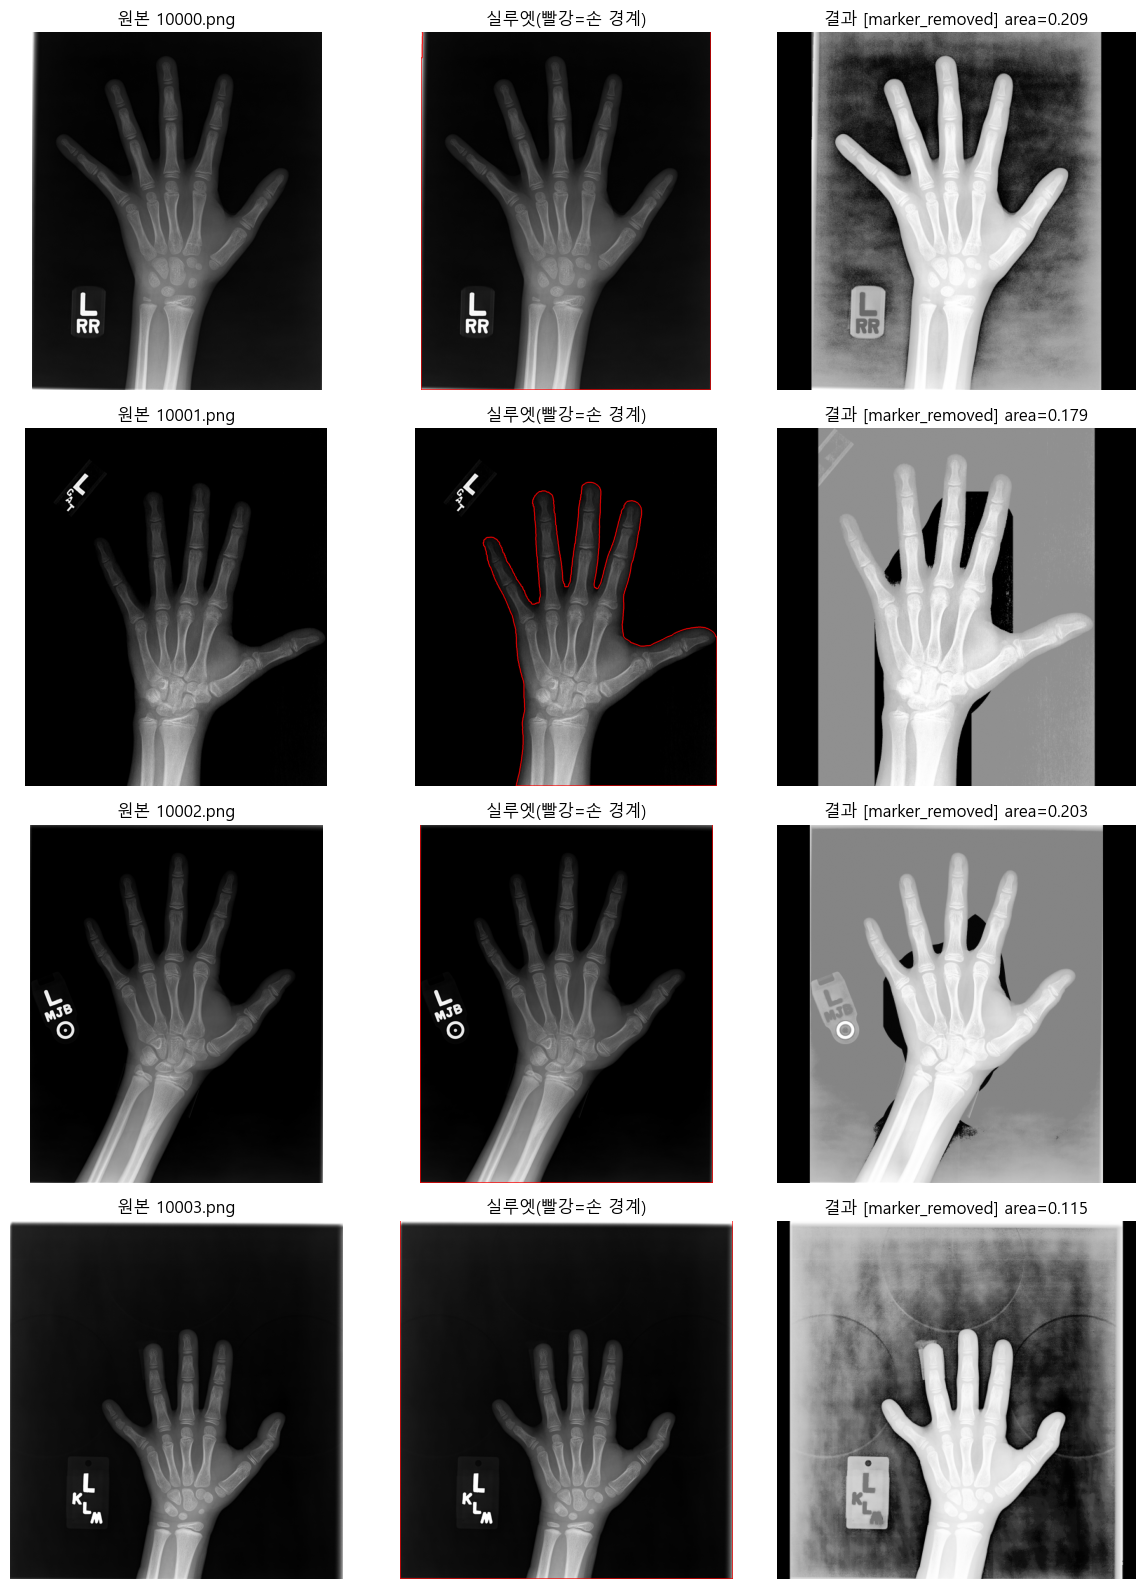


[튜닝 가이드]
· 손끝/피부가 빨간 경계 밖으로 삐져나오면 → SKIN_DELTA 낮추기(예: 12→8) 또는 SILH_DILATE 키우기
· 경계가 손 밖 배경까지 번지면 → SKIN_DELTA 높이기 / SILH_DILATE 줄이기
· 배경 검은 여백이 싫으면 BG_MODE='keep'(기본), 깔끔한 검은 배경 원하면 'mask'


In [4]:
files = list_images(SRC_DIR)
print(f"총 이미지 수: {len(files)}")
assert files, "이미지를 찾지 못했습니다. SRC_DIR 경로를 확인하세요."

def _silhouette_overlay(p):
    # 손 실루엣(빨간 윤곽)을 원본 위에 겹쳐 손끝/피부 포착 여부를 눈으로 확인
    raw = imread_u(p)
    enh = enhance(raw)
    hand = select_hand(get_hand_mask(enh))
    if hand is None:
        return cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    enh2, _ = remove_markers(enh, hand)
    silh = get_hand_silhouette(enh2, hand)
    rgb = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    cnts, _ = cv2.findContours(silh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(rgb, cnts, -1, (255, 0, 0), max(2, raw.shape[0] // 400))
    return rgb

sample = files[:4]
fig, axes = plt.subplots(len(sample), 3, figsize=(12, 4 * len(sample)))
if len(sample) == 1:
    axes = axes.reshape(1, 3)
for i, p in enumerate(sample):
    raw = imread_u(p)
    if raw is None:
        raise RuntimeError(f"이미지를 읽지 못했습니다(경로/파일 확인): {p}")
    out, meta = preprocess_one(p)
    axes[i, 0].imshow(raw, cmap="gray"); axes[i, 0].set_title(f"원본 {p.name}"); axes[i, 0].axis("off")
    axes[i, 1].imshow(_silhouette_overlay(p)); axes[i, 1].set_title("실루엣(빨강=손 경계)"); axes[i, 1].axis("off")
    axes[i, 2].imshow(out, cmap="gray")
    axes[i, 2].set_title(f"결과 [{meta['status']}] area={meta['area_frac']}")
    axes[i, 2].axis("off")
plt.tight_layout(); plt.show()

print("\n[튜닝 가이드]")
print("· 손끝/피부가 빨간 경계 밖으로 삐져나오면 → SKIN_DELTA 낮추기(예: 12→8) 또는 SILH_DILATE 키우기")
print("· 경계가 손 밖 배경까지 번지면 → SKIN_DELTA 높이기 / SILH_DILATE 줄이기")
print("· 배경 검은 여백이 싫으면 BG_MODE='keep'(기본), 깔끔한 검은 배경 원하면 'mask'")

## 4. 전체 배치 전처리 (캐시 · 스킵)

`LIMIT=None` 으로 바꾸면 전체를 처리합니다. 중단 후 다시 실행하면 이미 만든 파일은 건너뜁니다.

In [5]:
files = list_images(SRC_DIR)
if LIMIT:
    files = files[:LIMIT]

qc_path = QC_DIR / "qc_log.csv"
processed, skipped, excluded = 0, 0, 0
rows = []

for p in tqdm(files, desc="전처리"):
    if p.stem in EXCLUDE_IDS:                 # 이상 이미지 → 전처리/저장 제외
        excluded += 1
        out_path = OUTPUT_DIR / p.name
        if out_path.exists():                 # 과거에 만들어졌다면 삭제
            out_path.unlink()
        continue
    out_path = OUTPUT_DIR / p.name
    if SKIP_EXISTING and out_path.exists():
        skipped += 1
        continue
    out, meta = preprocess_one(p)
    rows.append({"filename": p.name, **meta})
    if out is not None:
        imwrite_u(out_path, out)
        processed += 1

# QC 로그 저장(이번 실행분 append)
if rows:
    write_header = not qc_path.exists()
    with open(qc_path, "a", newline="", encoding="utf-8-sig") as f:
        w = csv.DictWriter(f, fieldnames=["filename", "status", "removed", "ms", "area_frac"])
        if write_header:
            w.writeheader()
        w.writerows(rows)

print(f"처리 {processed}장 · 건너뜀 {skipped}장 · 제외(이상) {excluded}장")
print("QC 로그 →", qc_path)

전처리: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12611/12611 [55:22<00:00,  3.80it/s]

처리 12596장 · 건너뜀 0장 · 제외(이상) 15장
QC 로그 → C:\Users\Win11Pro\Desktop\뼈데이터\전처리\qc\qc_log.csv


## 5. QC 요약 · 서스펙트 추출

In [6]:
qc = pd.read_csv(QC_DIR / "qc_log.csv").drop_duplicates("filename", keep="last")

print("상태별 분포")
print(qc["status"].value_counts().to_string())
print(f"\n평균 처리시간: {qc['ms'].mean():.1f} ms/장")
print(f"rescue 비율: {(qc['status'] == 'rescue').mean() * 100:.1f}%  ← 이 값이 낮을수록 검출 품질 양호")

# 서스펙트: rescue 되었거나 면적비가 비정상인 것
suspects = qc[(qc["status"] == "rescue") |
              (qc["area_frac"] < MIN_AREA_FRAC) |
              (qc["area_frac"] > MAX_AREA_FRAC)]
sus_path = QC_DIR / "suspects.csv"
suspects.to_csv(sus_path, index=False, encoding="utf-8-sig")
print(f"\n서스펙트 {len(suspects)}장 → {sus_path}")
print("→ 육안 확인 후, 보정이 필요하면 manual_bbox.csv (filename,x,y,w,h) 를 만들어 다음 셀 실행")

상태별 분포
status
marker_removed    11288
ok                 1294
rescue               14

평균 처리시간: 252.7 ms/장
rescue 비율: 0.1%  ← 이 값이 낮을수록 검출 품질 양호

서스펙트 14장 → C:\Users\Win11Pro\Desktop\뼈데이터\전처리\qc\suspects.csv
→ 육안 확인 후, 보정이 필요하면 manual_bbox.csv (filename,x,y,w,h) 를 만들어 다음 셀 실행


## 6. (선택) 2-pass 수동 bbox 보정

`qc/manual_bbox.csv` 에 `filename,x,y,w,h` 컬럼으로 지정하면 해당 이미지만 그 bbox로 재크롭하여 덮어씁니다.

In [7]:
manual_path = QC_DIR / "manual_bbox.csv"

if manual_path.exists():
    mdf = pd.read_csv(manual_path)
    fixed = 0
    for _, r in mdf.iterrows():
        src = SRC_DIR / r["filename"]
        if not src.exists():
            print("원본 없음:", r["filename"]); continue
        img = enhance(imread_u(src))
        x, y, w, h = int(r["x"]), int(r["y"]), int(r["w"]), int(r["h"])
        crop = img[y:y + h, x:x + w]
        imwrite_u(OUTPUT_DIR / r["filename"], _square_resize(crop))
        fixed += 1
    print(f"수동 보정 {fixed}장 완료")
else:
    print("manual_bbox.csv 없음 → 건너뜀")
    print("경로:", manual_path)

manual_bbox.csv 없음 → 건너뜀
경로: C:\Users\Win11Pro\Desktop\뼈데이터\전처리\qc\manual_bbox.csv


## 7. 결과 시각화

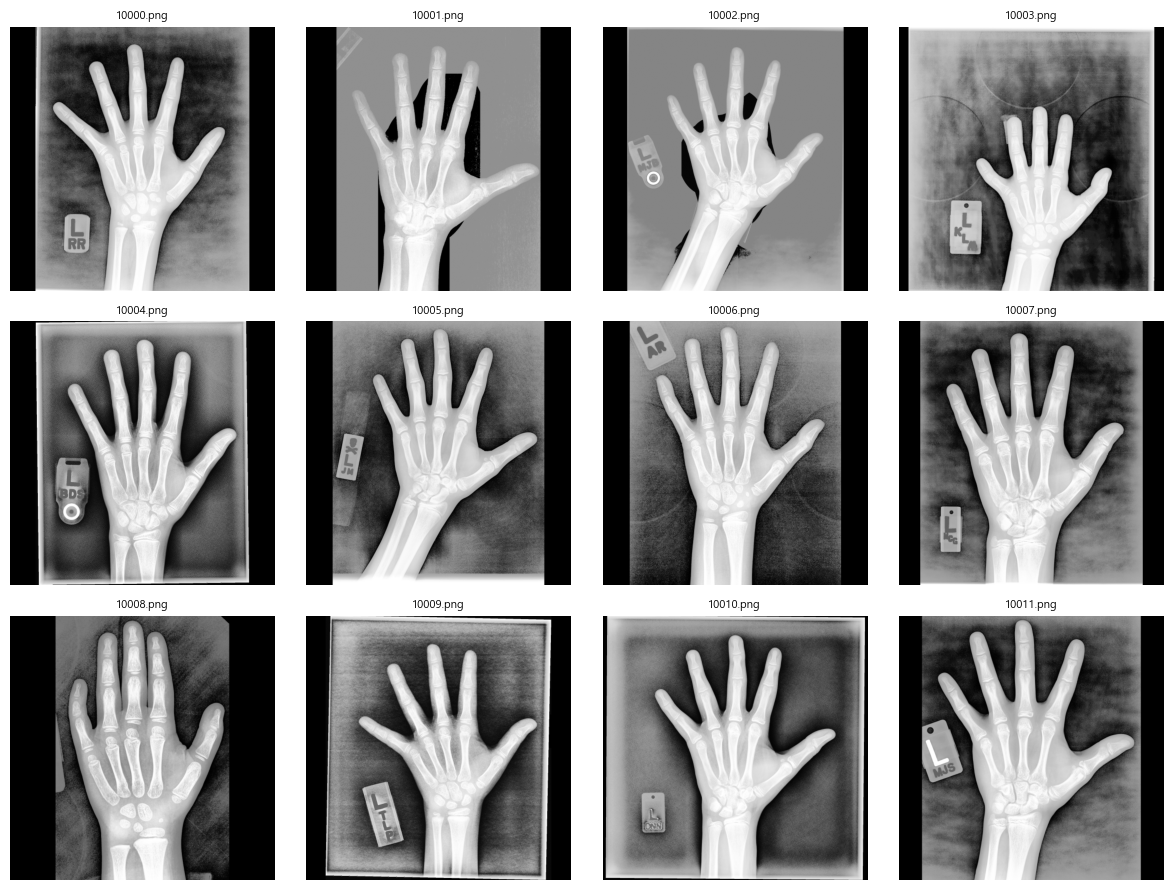

In [8]:
out_files = sorted(OUTPUT_DIR.glob("*.png"))[:12]
if out_files:
    cols = 4
    rows_n = (len(out_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(3 * cols, 3 * rows_n))
    axes = np.array(axes).reshape(-1)
    for ax, p in zip(axes, out_files):
        ax.imshow(imread_u(p), cmap="gray")
        ax.set_title(p.name, fontsize=8); ax.axis("off")
    for ax in axes[len(out_files):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("출력 이미지가 아직 없습니다. 배치 셀(4)을 먼저 실행하세요.")